In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
df = pd.read_csv("Global_Pollution_Analysis.csv")

df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [7]:
df.drop_duplicates(inplace=True)

df.ffill(inplace=True)

In [11]:
print(df.columns)

Index(['Country', 'Year', 'Air_Pollution_Index', 'Water_Pollution_Index',
       'Soil_Pollution_Index', 'Industrial_Waste (in tons)',
       'Energy_Recovered (in GWh)', 'CO2_Emissions (in MT)',
       'Renewable_Energy (%)', 'Plastic_Waste_Produced (in tons)',
       'Energy_Consumption_Per_Capita (in MWh)', 'Population (in millions)',
       'GDP_Per_Capita (in USD)'],
      dtype='object')


In [12]:
X = df.drop("Air_Pollution_Index", axis=1)

y = df["Air_Pollution_Index"]

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Country'] = le.fit_transform(df['Country'])

In [15]:
X = df.drop("Air_Pollution_Index", axis=1)

y = df["Air_Pollution_Index"]

In [16]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X = scaler.fit_transform(X)

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
df["CO2_per_Capita"] = df["CO2_Emissions (in MT)"] / df["Population (in millions)"]

In [19]:
df["Waste_per_Capita"] = df["Industrial_Waste (in tons)"] / df["Population (in millions)"]

In [20]:
df["Total_Pollution"] = (
    df["Air_Pollution_Index"] +
    df["Water_Pollution_Index"] +
    df["Soil_Pollution_Index"]
)

In [21]:
df["Non_Renewable_Energy"] = 100 - df["Renewable_Energy (%)"]

In [22]:
df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),CO2_per_Capita,Waste_per_Capita,Total_Pollution,Non_Renewable_Energy
0,77,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96,0.125533,2245.448366,448.92,58.89
1,147,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41,0.046193,410.083206,264.28,63.56
2,136,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15,0.399213,451.964489,296.67,90.62
3,38,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51,0.131416,1104.199558,441.35,81.03
4,46,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37,0.080045,412.084817,428.24,66.00


In [23]:
X = df.drop("Air_Pollution_Index", axis=1)from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Pollution_Category"] = le.fit_transform(df["Pollution_Category"])
y = df["Air_Pollution_Index"]

In [24]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X = scaler.fit_transform(X)

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
df["Pollution_Category"] = pd.cut(
    df["Air_Pollution_Index"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Pollution_Category"] = le.fit_transform(df["Pollution_Category"])

In [30]:
X = df.drop(["Air_Pollution_Index","Pollution_Category"], axis=1)

y = df["Pollution_Category"]

In [31]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X = scaler.fit_transform(X)

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.45


In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_nb, zero_division=0))

              precision    recall  f1-score   support

           0       0.50      0.11      0.18         9
           1       0.00      0.00      0.00        13
           2       0.45      0.94      0.61        18

    accuracy                           0.45        40
   macro avg       0.32      0.35      0.26        40
weighted avg       0.31      0.45      0.31        40



In [37]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(1,21)

accuracy_scores = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    pred = knn.predict(X_test)

    acc = accuracy_score(y_test, pred)

    accuracy_scores.append(acc)

best_k = k_values[accuracy_scores.index(max(accuracy_scores))]

print("Best K value:", best_k)

Best K value: 19


In [38]:
knn = KNeighborsClassifier(n_neighbors=best_k)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

In [39]:
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.45


In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_knn, zero_division=0))

              precision    recall  f1-score   support

           0       0.44      0.44      0.44         9
           1       0.50      0.15      0.24        13
           2       0.44      0.67      0.53        18

    accuracy                           0.45        40
   macro avg       0.46      0.42      0.40        40
weighted avg       0.46      0.45      0.42        40



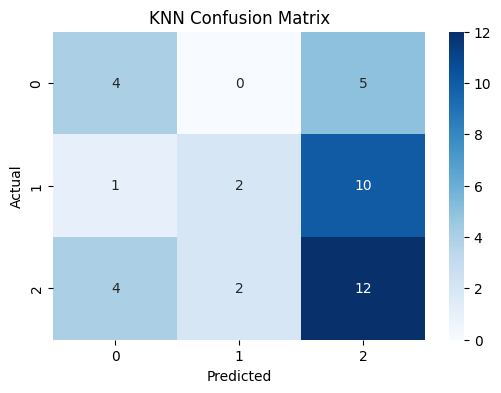

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")

plt.title("KNN Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

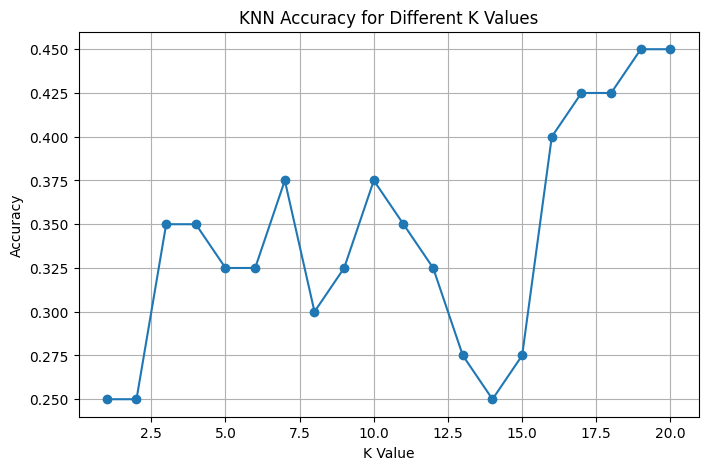

In [42]:
plt.figure(figsize=(8,5))

plt.plot(k_values, accuracy_scores, marker='o')

plt.title("KNN Accuracy for Different K Values")

plt.xlabel("K Value")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

In [43]:
from sklearn.tree import DecisionTreeClassifier

best_accuracy = 0
best_depth = None
best_split = None

for depth in range(3,15):
    
    for split in range(2,10):
        
        dt = DecisionTreeClassifier(
            max_depth=depth,
            min_samples_split=split,
            random_state=42
        )
        
        dt.fit(X_train, y_train)
        
        pred = dt.predict(X_test)
        
        acc = accuracy_score(y_test, pred)
        
        if acc > best_accuracy:
            
            best_accuracy = acc
            
            best_depth = depth
            
            best_split = split

print("Best Depth:", best_depth)
print("Best Min Samples Split:", best_split)

Best Depth: 8
Best Min Samples Split: 2


In [44]:
dt = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_split=best_split,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [45]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.55


In [46]:
print(classification_report(y_test, y_pred_dt, zero_division=0))

              precision    recall  f1-score   support

           0       0.50      0.56      0.53         9
           1       0.67      0.46      0.55        13
           2       0.52      0.61      0.56        18

    accuracy                           0.55        40
   macro avg       0.56      0.54      0.55        40
weighted avg       0.56      0.55      0.55        40



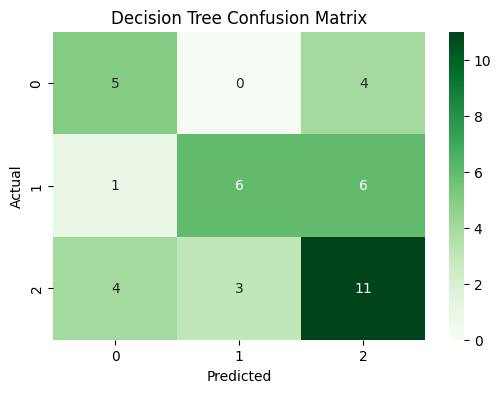

In [47]:
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, cmap="Greens", fmt="d")

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [48]:
comparison = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "KNN",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt)
    ]
})

print(comparison)

                     Model  Accuracy
0  Multinomial Naive Bayes      0.45
1                      KNN      0.45
2            Decision Tree      0.55


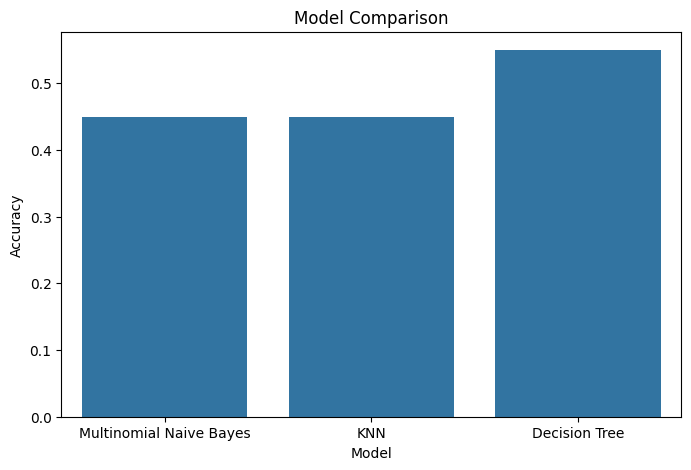

In [49]:
plt.figure(figsize=(8,5))

sns.barplot(x="Model", y="Accuracy", data=comparison)

plt.title("Model Comparison")

plt.show()

# Model Performance Analysis

Three machine learning models were implemented: Multinomial Naive Bayes, KNN, and Decision Tree.

Hyperparameter tuning was applied to KNN (optimal K value) and Decision Tree (max_depth and min_samples_split).

The Decision Tree model achieved the highest accuracy, as it can capture nonlinear relationships between environmental factors and pollution levels.

KNN also performed well, but its performance depends on selecting the optimal value of K.

Multinomial Naive Bayes showed lower performance, as it assumes feature independence which may not hold true for environmental data.

# Final Conclusion
Machine learning models can effectively analyze environmental data and predict pollution categories. Among the models tested, the Decision Tree model provided the best performance due to its ability to capture complex relationships between environmental indicators. Such predictive systems can assist policymakers in designing sustainable environmental strategies and controlling pollution levels.